In [1]:
import xml.etree.ElementTree as ET
import pandas as pd
from pathlib import Path

In [8]:
RAW_XML_PATH = Path("../data/raw/export.xml")
PROCESSED_PATH = Path("../data/processed/apple_health.csv")

In [ ]:
# --- 1. Parse XML
tree = ET.parse(RAW_XML_PATH)
root = tree.getroot()

attrs = set()
for i, record in enumerate(root.findall('Record')):
    attrs.update(record.attrib.keys())
    if i > 1000:
        break
print(attrs)


{'sourceVersion', 'type', 'value', 'creationDate', 'endDate', 'unit', 'startDate', 'sourceName'}


In [13]:
records = []
for record in root.findall('Record'):
    rtype = record.get('type')
    start = record.get('startDate')
    end = record.get('endDate')
    value = record.get('value')
    unit = record.get('unit')
    source = record.get('sourceName')
    records.append((rtype, start, end, value, unit, source))
df = pd.DataFrame(records, columns=["rtype","start","end","value","unit","source"])

In [35]:
df['rtype'] = df['rtype'].str.split("Identifier").str[-1]

In [60]:
df['rtype'].unique()


array(['BloodGlucose', 'DietaryWater', 'BodyMassIndex', 'Height',
       'BodyMass', 'HeartRate', 'OxygenSaturation', 'RespiratoryRate',
       'BodyFatPercentage', 'LeanBodyMass', 'StepCount',
       'DistanceWalkingRunning', 'BasalEnergyBurned',
       'ActiveEnergyBurned', 'FlightsClimbed', 'DietaryFatTotal',
       'DietaryFatPolyunsaturated', 'DietaryFatMonounsaturated',
       'DietaryFatSaturated', 'DietaryCholesterol', 'DietarySodium',
       'DietaryCarbohydrates', 'DietaryFiber', 'DietarySugar',
       'DietaryEnergyConsumed', 'DietaryProtein', 'DietaryVitaminA',
       'DietaryVitaminB6', 'DietaryVitaminB12', 'DietaryVitaminC',
       'DietaryVitaminD', 'DietaryVitaminE', 'DietaryVitaminK',
       'DietaryCalcium', 'DietaryIron', 'DietaryThiamin',
       'DietaryRiboflavin', 'DietaryNiacin', 'DietaryFolate',
       'DietaryBiotin', 'DietaryPantothenicAcid', 'DietaryPhosphorus',
       'DietaryIodine', 'DietaryMagnesium', 'DietaryZinc',
       'DietarySelenium', 'DietaryCoppe

In [70]:
start_date = "2025-07-28"  # first day of CGM
df = df[df['start'] >= start_date]

In [71]:
dietary_df = df[df['rtype'].str.startswith("Dietary", na=False)]
dietary_df.groupby('rtype')['value'].count().sort_values(ascending=False)


rtype
DietaryEnergyConsumed        99
DietaryProtein               97
DietaryCarbohydrates         96
DietaryFatTotal              95
DietaryCalcium               92
DietaryFatSaturated          92
DietarySodium                92
DietarySugar                 91
DietaryIron                  89
DietaryPotassium             87
DietaryFiber                 86
DietaryFatPolyunsaturated    78
DietaryFatMonounsaturated    77
DietaryNiacin                71
DietaryPhosphorus            71
DietaryThiamin               71
DietaryZinc                  71
DietaryMagnesium             71
DietaryManganese             70
DietaryRiboflavin            70
DietaryFolate                70
DietaryCopper                70
DietaryPantothenicAcid       69
DietaryVitaminB6             69
DietaryVitaminE              67
DietarySelenium              66
DietaryVitaminA              65
DietaryVitaminC              63
DietaryCholesterol           59
DietaryVitaminK              57
DietaryWater                 43
Di

In [72]:
df[df['rtype'] == "DietaryEnergyConsumed"]

,rtype,start,end,value,unit,source
2042742,DietaryEnergyConsumed,2025-07-30 09:37:00 -0400,2025-07-30 09:37:00 -0400,408.376,Cal,MyFitnessPal
2042743,DietaryEnergyConsumed,2025-07-30 08:00:00 -0400,2025-07-30 08:00:00 -0400,336,Cal,MyFitnessPal
2042744,DietaryEnergyConsumed,2025-07-30 08:00:00 -0400,2025-07-30 08:00:00 -0400,130,Cal,MyFitnessPal
2042745,DietaryEnergyConsumed,2025-07-30 08:01:00 -0400,2025-07-30 08:01:00 -0400,610.849,Cal,MyFitnessPal
2042746,DietaryEnergyConsumed,2025-07-31 08:05:00 -0400,2025-07-31 08:05:00 -0400,164.146,Cal,MyFitnessPal
...,...,...,...,...,...,...
2042836,DietaryEnergyConsumed,2025-08-14 08:23:32 -0400,2025-08-14 08:23:32 -0400,90,Cal,Bevel
2042837,DietaryEnergyConsumed,2025-08-14 08:23:32 -0400,2025-08-14 08:23:32 -0400,20.6625,Cal,Bevel
2042838,DietaryEnergyConsumed,2025-08-14 12:26:39 -0400,2025-08-14 12:26:39 -0400,432.756,Cal,Bevel
2042839,DietaryEnergyConsumed,2025-08-14 14:00:22 -0400,2025-08-14 14:00:22 -0400,162.12,Cal,Bevel


In [73]:
sampled_df = df.drop_duplicates(subset="rtype", keep="last")
sampled_df


,rtype,start,end,value,unit,source
4016,BloodGlucose,2025-08-11 18:10:42 -0400,2025-08-11 18:10:42 -0400,4.4406,mmol<180.1558800000541>/L,Lingo
4059,DietaryWater,2025-08-14 12:26:39 -0400,2025-08-14 12:26:39 -0400,185.788,mL,Bevel
4528,BodyMassIndex,2025-08-12 23:34:08 -0400,2025-08-12 23:34:08 -0400,18,count,VeSync
5289,BodyMass,2025-08-12 23:34:08 -0400,2025-08-12 23:34:08 -0400,44.95,kg,VeSync
398399,HeartRate,2025-08-16 09:04:24 -0400,2025-08-16 09:04:24 -0400,56,count/min,Kay’s Apple Watch
...,...,...,...,...,...,...
2812960,SleepAnalysis,2025-08-15 08:10:21 -0400,2025-08-15 08:12:21 -0400,HKCategoryValueSleepAnalysisAsleepCore,None,Kay’s Apple Watch
2827791,AppleStandHour,2025-08-16 09:00:00 -0400,2025-08-16 10:00:00 -0400,HKCategoryValueAppleStandHourStood,None,Kay’s Apple Watch
2828112,LowHeartRateEvent,2025-08-14 00:41:09 -0400,2025-08-14 00:51:09 -0400,HKCategoryValueNotApplicable,None,Kay’s Apple Watch
2828205,AudioExposureEvent,2025-08-07 21:23:53 -0400,2025-08-07 21:26:48 -0400,HKCategoryValueEnvironmentalAudioExposureEvent...,None,Kay’s Apple Watch


In [74]:
# 1) Define what to keep (using your cleaned rtype strings)
keep = {
    # glucose
    "BloodGlucose": "glucose_mmol",

    # dietary
    "DietaryCarbohydrates": "carbs_g",
    "DietaryFiber": "fiber_g",
    "DietarySugar": "sugar_g",
    "DietaryProtein": "protein_g",
    "DietaryFatTotal": "fat_g",
    "DietaryEnergyConsumed": "kcal",
    "DietaryCaffeine": "caffeine_mg",
    "NumberOfAlcoholicBeverages": "alcohol_drinks",

    # movement
    "StepCount": "steps",
    "AppleExerciseTime": "ex_minutes",
    "ActiveEnergyBurned": "active_kcal",
    "DistanceWalkingRunning": "walkrun_km",
    "FlightsClimbed": "flights",

    # heart/physiology
    "HeartRate": "hr_bpm",
    "RestingHeartRate": "rest_hr_bpm",
    "HeartRateRecoveryOneMinute": "hr_recov1m",

    # sleep (category; you’ll convert to flag later)
    "SleepAnalysis": "sleep_state",
}

# 2) Filter down to just these rtypes
df_keep = df[df['rtype'].isin(keep.keys())].copy()
df_keep['signal'] = df_keep['rtype'].map(keep)
df_keep = df_keep.dropna(subset=['value'])

# 3) Convert timestamps & numeric values
df_keep['start'] = pd.to_datetime(df_keep['start'], errors='coerce')
df_keep['value'] = pd.to_numeric(df_keep['value'], errors='coerce')

# 4) Split into quantity vs category
qty = df_keep[df_keep['signal'] != 'sleep_state'][['start','signal','value']]
cat = df_keep[df_keep['signal'] == 'sleep_state'][['start','end','signal','value']]


In [75]:
qty = df_keep[df_keep['signal'] != 'sleep_state'][['start','signal','value']]

wide = (
    qty
    .pivot_table(index='start', columns='signal', values='value', aggfunc='mean') # for glucose, HR
    .sort_index()
)


In [76]:
# First resample with sensible rules
agg_rules = {
    'steps': 'sum',
    'ex_minutes': 'sum',
    'active_kcal': 'sum',
    'walkrun_km': 'sum',
    'flights': 'sum',
    'carbs_g': 'sum',
    'fiber_g': 'sum',
    'sugar_g': 'sum',
    'protein_g': 'sum',
    'fat_g': 'sum',
    'kcal': 'sum',
    'caffeine_mg': 'sum',
    'alcohol_drinks': 'sum',
    'hr_bpm': 'mean',
    'rest_hr_bpm': 'mean',
    'hr_recov1m': 'mean',
    'glucose_mmol': 'mean',   # glucose is usually sparse, but keep as mean
}

wide_5min = wide.resample('5min').agg(agg_rules)

In [77]:
df_keep.head()

,rtype,start,end,value,unit,source,signal
0,BloodGlucose,2025-07-28 19:00:42-04:00,2025-07-28 19:00:42 -0400,4.16306,mmol<180.1558800000541>/L,Lingo,glucose_mmol
1,BloodGlucose,2025-07-28 19:05:42-04:00,2025-07-28 19:05:42 -0400,4.66263,mmol<180.1558800000541>/L,Lingo,glucose_mmol
2,BloodGlucose,2025-07-28 19:10:42-04:00,2025-07-28 19:10:42 -0400,4.94017,mmol<180.1558800000541>/L,Lingo,glucose_mmol
3,BloodGlucose,2025-07-28 19:15:42-04:00,2025-07-28 19:15:42 -0400,5.32872,mmol<180.1558800000541>/L,Lingo,glucose_mmol
4,BloodGlucose,2025-07-28 19:20:42-04:00,2025-07-28 19:20:42 -0400,4.94017,mmol<180.1558800000541>/L,Lingo,glucose_mmol


In [78]:
cat = df_keep[df_keep['signal'] == 'sleep_state'][['start','end','value']]
sleep_rows = []
for _, r in cat.dropna(subset=['start','end']).iterrows():
    rng = pd.date_range(r['start'], pd.to_datetime(r['end']), freq='5min')
    sleep_rows.append(pd.Series(1, index=rng))

if sleep_rows:
    sleep_flag = pd.concat(sleep_rows, axis=1).sum(axis=1).clip(upper=1)
    wide_5min['asleep'] = sleep_flag.reindex(wide_5min.index, fill_value=0)
else:
    wide_5min['asleep'] = 0


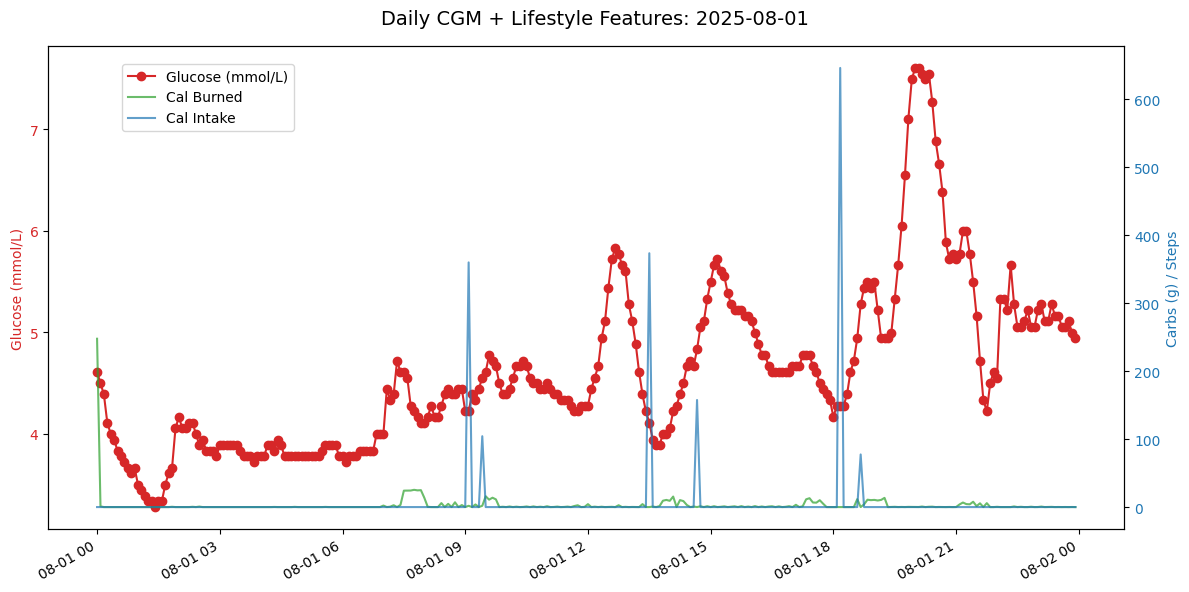

In [90]:
import matplotlib.pyplot as plt

# Pick a single day that you know has glucose & lifestyle data
day = "2025-08-01"  # <-- change this to a date you have in your dataset

day_df = wide_5min.loc[day]

fig, ax1 = plt.subplots(figsize=(12,6))

# --- Plot glucose on the left y-axis ---
ax1.plot(day_df.index, day_df['glucose_mmol'], color='tab:red', marker='o', linestyle='-', label='Glucose (mmol/L)')
ax1.set_ylabel('Glucose (mmol/L)', color='tab:red')
ax1.tick_params(axis='y', labelcolor='tab:red')

# --- Create second y-axis for carbs/steps ---
ax2 = ax1.twinx()
# ax2.bar(day_df.index, day_df['carbs_g'], width=0.003, color='tab:blue', alpha=0.5, label='Carbs (g)')
# ax2.plot(day_df.index, day_df['steps'], color='tab:green', alpha=0.7, label='Steps')
ax2.plot(day_df.index, day_df['active_kcal'], color='tab:green', alpha=0.7, label='Cal Burned')
ax2.plot(day_df.index, day_df['kcal'], color='tab:blue', alpha=0.7, label='Cal Intake')
ax2.set_ylabel('Carbs (g) / Steps', color='tab:blue')
ax2.tick_params(axis='y', labelcolor='tab:blue')

# --- Format ---
fig.suptitle(f"Daily CGM + Lifestyle Features: {day}", fontsize=14)
fig.autofmt_xdate()
fig.legend(loc='upper left', bbox_to_anchor=(0.1, 0.9))

plt.tight_layout()
plt.show()